# In this tutorial, we present some of the code used in the article entitled 'Entropy-based regularized regression for advanced distribution of relaxation times deconvolution' (DOI: j.jpowsour.2025.236910).

In [1]:
# import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import time
from math import log10, pi, sin, cos, log
from scipy.linalg import null_space
from scipy.optimize import minimize
from bayes_opt import BayesianOptimization
import cvxpy as cp
import os

# custom module import
import compute_DRT

In [2]:
# plot settings
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=15)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

# colors for the figures
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

# 1. Generate artificial impedance data based on the distant double ZARC model

## 1.1 Define the functions

In [3]:
def fct_Z_ZARC_exact(freq_vec, R_inf, R_ct, phi, tau_0):
    """
    computes exact impedance for ZARC model given the parameters.
    """
    omega = 2*pi*freq_vec
    Z_exact = R_inf + R_ct/(1.0 + (1j*omega*tau_0)**phi)
    
    N_freqs = len(freq_vec)
    Z_exact_re_im = np.zeros(2*N_freqs)
    Z_exact_re_im[:N_freqs] = Z_exact.real.flatten()
    Z_exact_re_im[N_freqs:] = Z_exact.imag.flatten()
    
    return Z_exact, Z_exact_re_im

def fct_gamma_ZARC_exact(tau_vec, R_ct, phi, tau_0):
    """
    computes gamma_exact for the ZARC model using a generic tau vector.
    """
    gamma_exact = (R_ct/(2*pi))*sin((1-phi)*pi)/(
        np.cosh(phi*np.log(tau_vec/tau_0)) - cos((1-phi)*pi)
    )
    return gamma_exact

def fct_Z_synth(Z_exact, sigma_n_exp=0.2, random_seed=1225):
    """
    adds synthetic noise to the impedance to simulate experimental data.
    """
    N_freqs = len(Z_exact)
    np.random.seed(random_seed)  # ensure reproducibility
    noise_real = np.random.normal(0, sigma_n_exp, N_freqs)
    noise_imag = np.random.normal(0, sigma_n_exp, N_freqs)
    Z_exp = Z_exact + (noise_real + 1j*noise_imag)
    
    Z_exp_re_im = np.zeros(2*N_freqs)
    Z_exp_re_im[:N_freqs] = Z_exp.real.flatten()
    Z_exp_re_im[N_freqs:] = Z_exp.imag.flatten()
    
    return Z_exp, Z_exp_re_im

def prob_RR(lambda_0, A, L, Z):
    """
    performs ridge regression with L2 regularization.
    """
    N_fs = np.size(Z)//2
    x = cp.Variable(A.shape[1], nonneg=True)
    objective = cp.Minimize(cp.norm(A@x-Z, p=2)**2 + lambda_0*cp.norm(L@x, p=2)**2)
    prob = cp.Problem(objective)
    prob.solve(solver=cp.MOSEK)
    
    x_val = x.value
    Z_hat = A@x_val
    Z_hat_cmplx = Z_hat[:N_fs] + 1j*Z_hat[N_fs:]
    
    return Z_hat_cmplx, x_val

def prob_entropy(lambda_0, A, Z):
    """
    solves an optimization problem with entropy regularization.
    """
    N_fs = np.size(Z)//2
    x = cp.Variable(A.shape[1], nonneg=True)
    objective = cp.Minimize(cp.norm(A@x-Z, p=2)**2 - lambda_0*cp.sum(cp.entr(x)))
    prob = cp.Problem(objective)
    prob.solve(solver=cp.MOSEK)
    
    x_val = x.value
    Z_hat = A@x_val
    Z_hat_cmplx = Z_hat[:N_fs] + 1j*Z_hat[N_fs:]
    
    return Z_hat_cmplx, x_val    
    
# define the objective function for bayesian optimization
def objective(log10_lambda_0, problem_func, A, L, Z_exp_re_im, gamma_exact):
    """
    Objective function for Bayesian optimization to minimize the norm difference
    between the calculated and exact gamma values.
    """
    lambda_reg = 10**log10_lambda_0  # convert lambda from log scale to linear scale
    
    # if l is none, it's for prob_entropy
    if L is None:
        Z_hat, x = problem_func(lambda_reg, A, Z_exp_re_im)
    else:
        Z_hat, x = problem_func(lambda_reg, A, L, Z_exp_re_im)
    
    # return negative norm difference, as bayesianoptimization maximizes the objective
    objective_val = -log10(np.linalg.norm(x[1:] - gamma_exact, 2))
    
    return objective_val

def perform_bo(problem_name, problem_func, A, L, Z_exp_re_im, gamma_exact, pbounds, random_state):
    """
    Performs Bayesian Optimization to find the optimal lambda for a given problem.
    Returns the optimal lambda, optimal Z, and optimal x.
    """
    optimizer = BayesianOptimization(
        f=lambda log10_lambda_0: objective(log10_lambda_0, problem_func, A, L, Z_exp_re_im, gamma_exact),
        pbounds=pbounds,
        random_state=random_state
    )
    optimizer.maximize(init_points=5, n_iter=30)
    
    # extract the optimal lambda value from the optimization results
    optimal_log10_lambda_0 = optimizer.max['params']['log10_lambda_0']
    optimal_lambda = 10**optimal_log10_lambda_0
    
    # solve the problem with the optimal lambda
    if L is None:
        Z_hat_BO_opt, x_BO_opt = problem_func(optimal_lambda, A, Z_exp_re_im)
    else:
        Z_hat_BO_opt, x_BO_opt = problem_func(optimal_lambda, A, L, Z_exp_re_im)
    
    # calculate errors for gamma and z
    error_gamma_BO = np.linalg.norm(x_BO_opt[1:] - gamma_exact)
    error_Z_BO = np.linalg.norm(A @ x_BO_opt - Z_exp_re_im)
    
    print(f"Optimal lambda ({problem_name}): {optimal_lambda}")
    print(f"Gamma error ({problem_name}): {error_gamma_BO}")
    print(f"Z error ({problem_name}): {error_Z_BO}\n")
    
    return optimal_lambda, Z_hat_BO_opt, x_BO_opt

## 1.2 Define the exact and experimental impedances 

In [4]:
# frequency range definition
N_freqs = 81
freq_min, freq_max = 1e-2, 1e6
freq_vec = np.logspace(log10(freq_min), log10(freq_max), num=N_freqs)

# parameters for ZARC model
R_inf_1, R_ct_1, phi_1, tau_1 = 10, 50, 0.8, 1E-2
R_inf_2, R_ct_2, phi_2, tau_2 = 0.0, 20, 0.8, 1E-4

# calculate the exact impedance
Z_exact_1, Z_exact_re_im_1 = fct_Z_ZARC_exact(freq_vec, R_inf_1, R_ct_1, phi_1, tau_1)
Z_exact_2, Z_exact_re_im_2 = fct_Z_ZARC_exact(freq_vec, R_inf_2, R_ct_2, phi_2, tau_2)

Z_exact = Z_exact_1 + Z_exact_2
Z_exact_re_im = Z_exact_re_im_1 + Z_exact_re_im_2

# add synthetic noise to the impedance
random_seed = 1225
sigma_n_exp = 0.5
Z_exp, Z_exp_re_im = fct_Z_synth(Z_exact, sigma_n_exp, random_seed=1225)

## 1.3 Define the exact DRT

In [5]:
# define the tau vector for DRT
N_tau = 81
tau_vec = np.logspace(-log10(freq_max), -log10(freq_min), num=N_tau)
log_tau_vec = np.log(tau_vec)

# finer tau vector for higher resolution
N_tau_fine = 801
tau_vec_fine = np.logspace(-log10(freq_max), -log10(freq_min), num=N_tau_fine)
log_tau_vec_fine = np.log(tau_vec_fine)

# compute the exact gamma
gamma_exact = fct_gamma_ZARC_exact(tau_vec, R_ct_1, phi_1, tau_1) +\
                fct_gamma_ZARC_exact(tau_vec, R_ct_2, phi_2, tau_2)

gamma_exact_fine = fct_gamma_ZARC_exact(tau_vec_fine, R_ct_1, phi_1, tau_1) +\
                    fct_gamma_ZARC_exact(tau_vec_fine, R_ct_2, phi_2, tau_2)

## 1.4 Plot the exact and experimental impedances

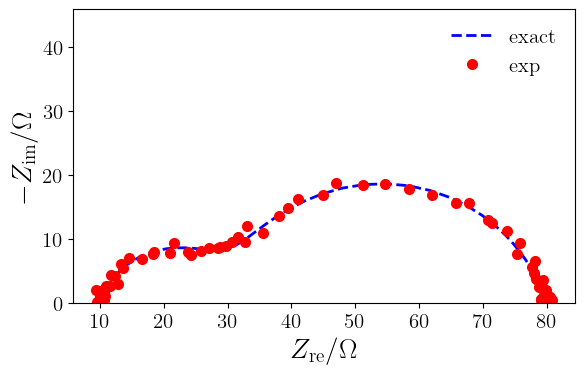

In [6]:
plt.plot(np.real(Z_exact), -np.imag(Z_exact), 'b--', linewidth=2, label='exact')
plt.plot(np.real(Z_exp), -np.imag(Z_exp), 'ro', markersize=7, label='exp')

plt.axis('scaled')
plt.ylim(0, 46)
plt.xticks(range(10, 90, 10))
plt.yticks(range(0, 50, 10))
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(frameon=False, fontsize = 15)
plt.xlabel(r'$Z_{\rm re}/\Omega$', fontsize = 20)
plt.ylabel(r'$-Z_{\rm im}/\Omega$', fontsize = 20)

fig = plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

# 2. Deconvolve the DRTs with ridge regression (RR) and with the entropy

## 2.1 Compute the discretization and differentiation matrices

In [7]:
# compute matrix A
A_complex = compute_DRT.compute_A_complex(freq_vec, log_tau_vec)
A_re = np.real(A_complex)
A_im = np.imag(A_complex)

A_R0 = np.zeros((2*N_freqs, 1))
A_R0[:N_freqs, 0] = 1.0
A = np.hstack((A_R0, np.vstack((A_re, A_im))))

# compute matrix L
id_standard = np.eye(len(log_tau_vec))
L1_standard = compute_DRT.compute_L1(log_tau_vec)
L2_standard = compute_DRT.compute_L2(log_tau_vec)

id_matrix = np.hstack((np.zeros((N_tau, 1)), id_standard))
L1 = np.hstack((np.zeros((N_tau-1, 1)), L1_standard))
L2 = np.hstack((np.zeros((N_tau-2, 1)), L2_standard))

## 2.2 Evaluate the impedance and DRT errors as functions of the regularization parameter

In [8]:
# sweep across lambda values for different regularization techniques
N_lambda = 161
lambda_values = np.logspace(-6, 2, N_lambda)

# preallocate arrays to store errors for Z and gamma
error_Z_RR_id = np.zeros(N_lambda)
error_Z_RR_L1 = np.zeros(N_lambda)
error_Z_RR_L2 = np.zeros(N_lambda)
error_Z_entropy = np.zeros(N_lambda)

error_gamma_RR_id = np.zeros(N_lambda)
error_gamma_RR_L1 = np.zeros(N_lambda)
error_gamma_RR_L2 = np.zeros(N_lambda)
error_gamma_entropy = np.zeros(N_lambda)

print('sweeping RR (Identity, L1, L2), and entropy models')

# iterate over the range of lambda values and store errors in preallocated arrays
for index_lambda, lambda_val in enumerate(lambda_values):
    print(f'lambda = {lambda_val}')

    # compute Z and gamma for ridge regression (RR) with identity, L1, and L2
    Z_RR_id, x_RR_id = prob_RR(lambda_val, A, id_matrix, Z_exp_re_im)
    Z_RR_L1, x_RR_L1 = prob_RR(lambda_val, A, L1, Z_exp_re_im)
    Z_RR_L2, x_RR_L2 = prob_RR(lambda_val, A, L2, Z_exp_re_im)

    # compute Z and gamma for entropy model
    Z_entropy, x_entropy = prob_entropy(lambda_val, A, Z_exp_re_im)

    # calculate and store errors for Z
    error_Z_RR_id[index_lambda] = np.linalg.norm(Z_exact - Z_RR_id)
    error_Z_RR_L1[index_lambda] = np.linalg.norm(Z_exact - Z_RR_L1)
    error_Z_RR_L2[index_lambda] = np.linalg.norm(Z_exact - Z_RR_L2)
    error_Z_entropy[index_lambda] = np.linalg.norm(Z_exact - Z_entropy)

    # calculate and store errors for gamma
    error_gamma_RR_id[index_lambda] = np.linalg.norm(x_RR_id[1:] - gamma_exact)
    error_gamma_RR_L1[index_lambda] = np.linalg.norm(x_RR_L1[1:] - gamma_exact)
    error_gamma_RR_L2[index_lambda] = np.linalg.norm(x_RR_L2[1:] - gamma_exact)
    error_gamma_entropy[index_lambda] = np.linalg.norm(x_entropy[1:] - gamma_exact)

sweeping RR (Identity, L1, L2), and entropy models
lambda = 1e-06
lambda = 1.122018454301963e-06
lambda = 1.2589254117941661e-06
lambda = 1.4125375446227554e-06
lambda = 1.584893192461114e-06
lambda = 1.778279410038923e-06
lambda = 1.9952623149688787e-06
lambda = 2.2387211385683376e-06
lambda = 2.5118864315095823e-06
lambda = 2.818382931264455e-06
lambda = 3.162277660168379e-06
lambda = 3.548133892335753e-06
lambda = 3.981071705534969e-06
lambda = 4.466835921509635e-06
lambda = 5.011872336272725e-06
lambda = 5.623413251903491e-06
lambda = 6.30957344480193e-06
lambda = 7.079457843841373e-06
lambda = 7.943282347242822e-06
lambda = 8.91250938133746e-06
lambda = 1e-05
lambda = 1.122018454301963e-05
lambda = 1.2589254117941661e-05
lambda = 1.4125375446227555e-05
lambda = 1.584893192461114e-05
lambda = 1.778279410038923e-05
lambda = 1.9952623149688786e-05
lambda = 2.238721138568338e-05
lambda = 2.5118864315095822e-05
lambda = 2.818382931264455e-05
lambda = 3.1622776601683795e-05
lambda = 3.5

## 2.3 Find the optimal regularization parameter for each deconvolution method

In [9]:
# find the lambda values that minimize the gamma error for each technique
min_error_gamma_RR_id = min(error_gamma_RR_id)
min_error_gamma_RR_L1 = min(error_gamma_RR_L1)
min_error_gamma_RR_L2 = min(error_gamma_RR_L2)
min_error_gamma_entropy = min(error_gamma_entropy)

optimal_lambda_RR_id = lambda_values[np.argmin(error_gamma_RR_id)]
optimal_lambda_RR_L1 = lambda_values[np.argmin(error_gamma_RR_L1)]
optimal_lambda_RR_L2 = lambda_values[np.argmin(error_gamma_RR_L2)]
optimal_lambda_entropy = lambda_values[np.argmin(error_gamma_entropy)]

# output the results for the 1D sweep
print('1) RR with identity')
print(f'optimal lambda_rr (1d, identity): {optimal_lambda_RR_id}')
print(f'minimum gamma error (1d, RR identity): {min_error_gamma_RR_id}')

print('2) RR with L1')
print(f'optimal lambda_rr (1d, L1): {optimal_lambda_RR_L1}')
print(f'minimum gamma error (1d, RR L1): {min_error_gamma_RR_L1}')

print('3) RR with L2')
print(f'optimal lambda_rr (1d, L2): {optimal_lambda_RR_L2}')
print(f'minimum gamma error (1d, RR L2): {min_error_gamma_RR_L2}')

print('4) entropy')
print(f'optimal lambda_entropy (1d): {optimal_lambda_entropy}')
print(f'minimum gamma error (1d, entropy): {min_error_gamma_entropy}')

# calculate the gamma corresponding to the optimal lambda values for Ridge Regression with Identity, L1, L2, and Entropy
Z_RR_id_opt, x_RR_id_opt = prob_RR(optimal_lambda_RR_id, A, id_matrix, Z_exp_re_im)  # Identity regularization
Z_RR_L1_opt, x_RR_L1_opt = prob_RR(optimal_lambda_RR_L1, A, L1, Z_exp_re_im)         # L1 regularization
Z_RR_L2_opt, x_RR_L2_opt = prob_RR(optimal_lambda_RR_L2, A, L2, Z_exp_re_im)         # L2 regularization
Z_entropy_opt, x_entropy_opt = prob_entropy(optimal_lambda_entropy, A, Z_exp_re_im)   # Entropy-based model

1) RR with identity
optimal lambda_rr (1d, identity): 0.008912509381337459
minimum gamma error (1d, RR identity): 9.716771684767778
2) RR with L1
optimal lambda_rr (1d, L1): 0.0012589254117941675
minimum gamma error (1d, RR L1): 9.528313362424074
3) RR with L2
optimal lambda_rr (1d, L2): 0.0001995262314968881
minimum gamma error (1d, RR L2): 9.394040689124804
4) entropy
optimal lambda_entropy (1d): 0.22387211385683423
minimum gamma error (1d, entropy): 4.886035739083945


## 2.4 Optimize the regularization parameter by minimizing the DRT error

In [10]:
# define bounds for the log of lambda
pbounds = {'log10_lambda_0': (-6, 2)}
random_state = 42

# 1. identity regularization
optimal_lambda_id_BO, Z_hat_id_BO, x_id_opt_BO = perform_bo(
    'id', prob_RR, A, id_matrix, Z_exp_re_im, gamma_exact, pbounds, random_state)

# 2. L1 regularization with BO flag
optimal_lambda_L1_BO, Z_hat_L1_BO, x_L1_opt_BO = perform_bo(
    'L1', prob_RR, A, L1, Z_exp_re_im, gamma_exact, pbounds, random_state)

# 3. L2 regularization with BO flag
optimal_lambda_L2_BO, Z_hat_L2_BO, x_L2_opt_BO = perform_bo(
    'L2', prob_RR, A, L2, Z_exp_re_im, gamma_exact, pbounds, random_state)

# 4. entropy regularization with BO flag
optimal_lambda_entropy_BO, Z_hat_entropy_BO, x_entropy_opt_BO = perform_bo(
    'entropy', prob_entropy, A, None, Z_exp_re_im, gamma_exact, pbounds, random_state)

# collect errors
error_Z_id_BO = np.linalg.norm(A @ x_id_opt_BO - Z_exact_re_im)
error_Z_L1_BO = np.linalg.norm(A @ x_L1_opt_BO - Z_exact_re_im)
error_Z_L2_BO = np.linalg.norm(A @ x_L2_opt_BO - Z_exact_re_im)
error_Z_entropy_BO = np.linalg.norm(A @ x_entropy_opt_BO - Z_exact_re_im)

error_gamma_id_BO = np.linalg.norm(x_id_opt_BO[1:] - gamma_exact)
error_gamma_L1_BO = np.linalg.norm(x_L1_opt_BO[1:] - gamma_exact)
error_gamma_L2_BO = np.linalg.norm(x_L2_opt_BO[1:] - gamma_exact)
error_gamma_entropy_BO = np.linalg.norm(x_entropy_opt_BO[1:] - gamma_exact)

# list of regularization methods
regularization_methods = ['id', 'L1', 'L2', 'entropy']
optimal_lambdas_BO = [optimal_lambda_id_BO, optimal_lambda_L1_BO, optimal_lambda_L2_BO, optimal_lambda_entropy_BO]
errors_gamma_BO = [error_gamma_id_BO, error_gamma_L1_BO, error_gamma_L2_BO, error_gamma_entropy_BO]
errors_Z_BO = [error_Z_id_BO, error_Z_L1_BO, error_Z_L2_BO, error_Z_entropy_BO]

|   iter    |  target   | log10_... |
-------------------------------------
| 1         | -1.170879 | -3.003679 |
| 2         | -1.665316 | 1.6057144 |
| 3         | -1.390197 | -0.144048 |
| 4         | -1.110129 | -1.210732 |
| 5         | -1.740046 | -4.751850 |
| 6         | -0.987782 | -2.092222 |
| 7         | -0.999739 | -1.826210 |
| 8         | -0.994268 | -2.214264 |
| 9         | -0.987679 | -2.033369 |
| 10        | -0.987523 | -2.049640 |
| 11        | -0.987523 | -2.051621 |
| 12        | -0.987518 | -2.052870 |
| 13        | -0.987514 | -2.053861 |
| 14        | -0.987511 | -2.054758 |
| 15        | -0.987518 | -2.055707 |
| 16        | -0.987519 | -2.056649 |
| 17        | -0.987519 | -2.057690 |
| 18        | -0.987530 | -2.048225 |
| 19        | -0.987538 | -2.063707 |
| 20        | -0.987538 | -2.062486 |
| 21        | -0.987562 | -2.043406 |
| 22        | -0.987538 | -2.064543 |
| 23        | -0.987538 | -2.063554 |
| 24        | -0.987556 | -2.044076 |
| 25        

## 3. Plot the recovered DRTs and impedances

## 3.1 Plot the DRT recovered with RR and the zeroth-order differentiation matrix (Figure S1 (b) in the Supplementary Information)

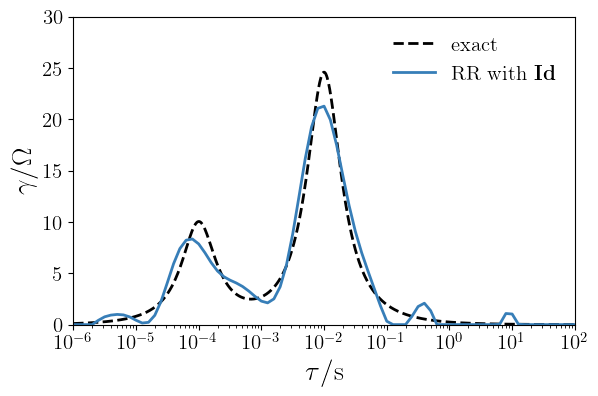

In [11]:
plt.semilogx(tau_vec_fine, gamma_exact_fine, '--', linewidth=2, color='black', label='exact')
plt.semilogx(tau_vec, x_id_opt_BO[1:], color=CB_color_cycle[0], linewidth=2, label=r'RR with $\mathbf{Id}$')

plt.axis([1E-6, 1E2, 0, 30])
plt.legend(frameon=False, fontsize = 15)
plt.xlabel(r'$\tau/\rm s$', fontsize = 20)
plt.ylabel(r'$\gamma/\Omega$', fontsize = 20)

fig = plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

## 3.2 Plot the DRT recovered with RR and the first-order differentiation matrix (Figure S1 (d))

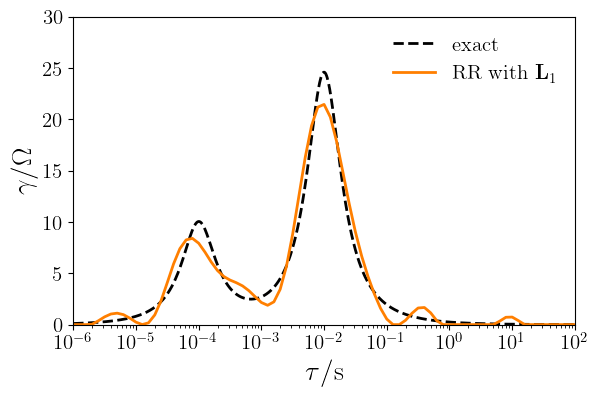

In [12]:
# DRT recovered with ridge regression and the first-order differentiation matrix (Figure S1 (d))
plt.semilogx(tau_vec_fine, gamma_exact_fine, '--', linewidth=2, color='black', label='exact')
plt.semilogx(tau_vec, x_L1_opt_BO[1:], color=CB_color_cycle[1], linewidth=2, label=r'RR with $\mathbf{L}_1$')

plt.axis([1E-6, 1E2, 0, 30])
plt.legend(frameon=False, fontsize = 15)
plt.xlabel(r'$\tau/\rm s$', fontsize = 20)
plt.ylabel(r'$\gamma/\Omega$', fontsize = 20)

fig = plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

## 3.3 Plot the DRT recovered with RR and the second-order differentiation matrix (Figure 1 (d) in the manuscript)

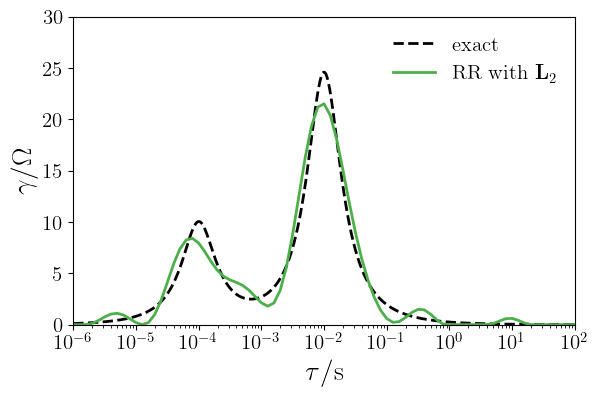

In [13]:
# DRT recovered with ridge regression and the second-order differentiation matrix (Figure 1 (d))
plt.semilogx(tau_vec_fine, gamma_exact_fine, '--', linewidth=2, color='black', label='exact')
plt.semilogx(tau_vec, x_L2_opt_BO[1:], color=CB_color_cycle[2], linewidth=2, label=r'RR with $\mathbf{L}_2$')

plt.axis([1E-6, 1E2, 0, 30])
plt.legend(frameon=False, fontsize = 15)
plt.xlabel(r'$\tau/\rm s$', fontsize = 20)
plt.ylabel(r'$\gamma/\Omega$', fontsize = 20)

fig = plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

## 3.4 Plot the DRT recovered with RR and the second-order differentiation matrix (Figure 1 (f))

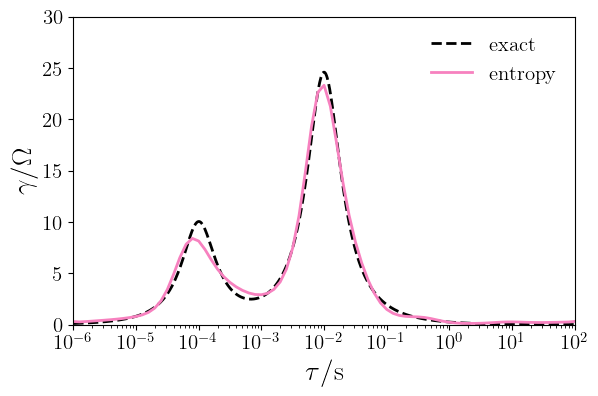

In [14]:
plt.semilogx(tau_vec_fine, gamma_exact_fine, '--', linewidth=2, color='black', label='exact')
plt.semilogx(tau_vec, x_entropy_opt_BO[1:], color=CB_color_cycle[3], linewidth=2, label=r'entropy')

plt.axis([1E-6, 1E2, 0, 30])
plt.legend(frameon=False, fontsize = 15)
plt.xlabel(r'$\tau/\rm s$', fontsize = 20)
plt.ylabel(r'$\gamma/\Omega$', fontsize = 20)

fig = plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

## 3.5 PLot the impedance recovered with RR and the second-order differentiation matrix (panels (a) and (c) of Figure 2)

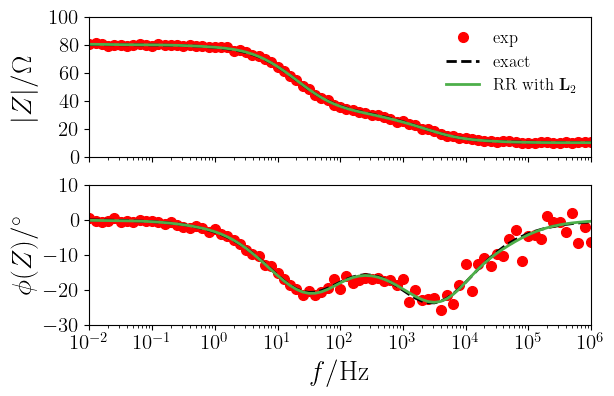

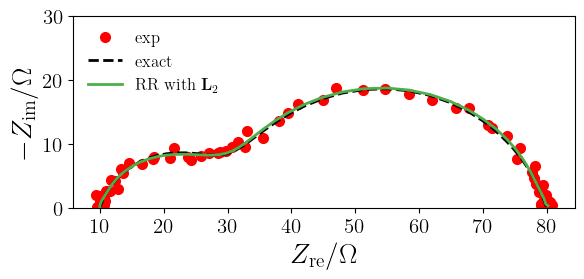

In [15]:
# Figure 2 (a)
fig, (ax1, ax2) = plt.subplots(2, sharex=True)
ax1.semilogx(freq_vec, np.abs(Z_exp), 'o', markersize=7, color='red', label='exp')
ax1.semilogx(freq_vec, np.abs(Z_exact), '--', linewidth=2, color='black', label='exact')
ax1.semilogx(freq_vec, np.abs(Z_hat_L2_BO), color=CB_color_cycle[2], linewidth=2, label=r'RR with $\mathbf{L}_2$')
ax1.set_ylabel(r'$|Z|/\Omega$', fontsize = 20)
ax1.axis([1E-2, 1E6, 0, 100])
ax1.set_yticks(np.arange(0, 100.1, step=20)) 
ax1.legend(frameon=False, fontsize = 12)
ax2.semilogx(freq_vec, np.angle(Z_exp, deg=True), 'o', markersize=7, color='red', label='exp')
ax2.semilogx(freq_vec, np.angle(Z_exact, deg=True), '--', linewidth=2, color='black', label='exact')
ax2.semilogx(freq_vec, np.angle(Z_hat_L2_BO, deg=True), color=CB_color_cycle[2], linewidth=2, label=r'RR with $\mathbf{L}_2$')
ax2.set_ylabel(r'$\phi(Z)/^{\circ}$', fontsize = 20)
ax2.axis([1E-2, 1E6, -30, 10])
ax2.set_yticks(np.arange(-30, 10.1, step=10)) 
plt.xlabel(r'$f/{\rm Hz}$', fontsize = 20)
fig.align_ylabels()
fig = plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

# Figure 2 (c)
plt.plot(np.real(Z_exp), -np.imag(Z_exp), 'ro', markersize=7, label='exp')
plt.plot(np.real(Z_exact), -np.imag(Z_exact), 'black', linestyle='--', linewidth=2, label='exact')
plt.plot(np.real(Z_hat_L2_BO), -np.imag(Z_hat_L2_BO), color=CB_color_cycle[2], linewidth=2, label=r'RR with $\mathbf{L}_2$')
plt.axis('scaled')
plt.ylim(0, 30)
plt.xticks(np.arange(10, 90, 10))
plt.yticks(np.arange(0, 30.1, 10))
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(frameon=False, fontsize = 12)
plt.xlabel(r'$Z_{\rm re}/\Omega$', fontsize = 20)
plt.ylabel(r'$-Z_{\rm im}/\Omega$', fontsize = 20)
fig = plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

## 3.6 PLot the impedance recovered with the entropy (panels (b) and (d) of Figure 2)

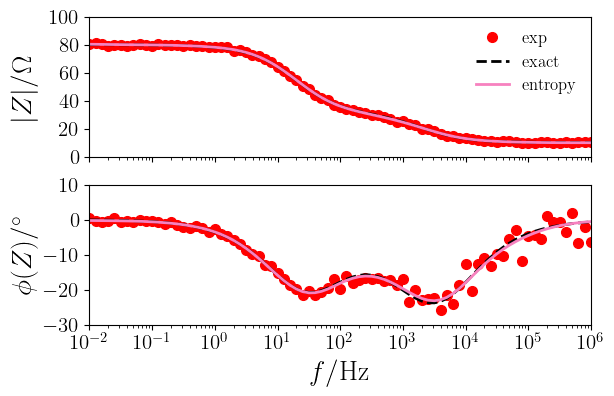

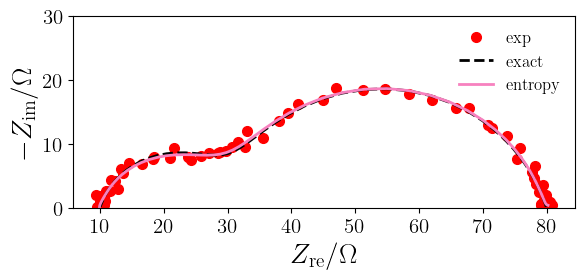

In [16]:
# Figure 2 (b)
fig, (ax1, ax2) = plt.subplots(2, sharex=True)
ax1.semilogx(freq_vec, np.abs(Z_exp), 'o', markersize=7, color='red', label='exp')
ax1.semilogx(freq_vec, np.abs(Z_exact), '--', linewidth=2, color='black', label='exact')
ax1.semilogx(freq_vec, np.abs(Z_hat_entropy_BO), color=CB_color_cycle[3], linewidth=2, label=r'entropy')
ax1.set_ylabel(r'$|Z|/\Omega$', fontsize = 20)
ax1.axis([1E-2, 1E6, 0, 100])
ax1.set_yticks(np.arange(0, 100.1, step=20)) 
ax1.legend(frameon=False, fontsize = 12)
ax2.semilogx(freq_vec, np.angle(Z_exp, deg=True), 'o', markersize=7, color='red', label='exp')
ax2.semilogx(freq_vec, np.angle(Z_exact, deg=True), '--', linewidth=2, color='black', label='exact')
ax2.semilogx(freq_vec, np.angle(Z_hat_entropy_BO, deg=True), color=CB_color_cycle[3], linewidth=2, label=r'entropy')
ax2.set_ylabel(r'$\phi(Z)/^{\circ}$', fontsize = 20)
ax2.axis([1E-2, 1E6, -30, 10])
ax2.set_yticks(np.arange(-30, 10.1, step=10)) 
plt.xlabel(r'$f/{\rm Hz}$', fontsize = 20)
fig.align_ylabels()
fig = plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

# Figure 2 (d)
plt.plot(np.real(Z_exp), -np.imag(Z_exp), 'ro', markersize=7, label='exp')
plt.plot(np.real(Z_exact), -np.imag(Z_exact), 'black', linestyle='--', linewidth=2, label='exact')
plt.plot(np.real(Z_hat_entropy_BO), -np.imag(Z_hat_entropy_BO), color=CB_color_cycle[3], linewidth=2, label=r'entropy')
plt.axis('scaled')
plt.ylim(0, 30)
plt.xticks(np.arange(10, 90, 10))
plt.yticks(np.arange(0, 30.1, 10))
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(frameon=False, fontsize = 12)
plt.xlabel(r'$Z_{\rm re}/\Omega$', fontsize = 20)
plt.ylabel(r'$-Z_{\rm im}/\Omega$', fontsize = 20)
fig = plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()